# Interactive Bandwidth Analysis
This notebook parses simulation logs and generates visualizations directly.

In [12]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid")

def strip_ansi(text):
    return re.sub(r"\x1b\[[0-9;]*[mK]", "", text)

def get_peer_info():
    peer_data = []
    data_dir = "shadow.data/hosts"
    if not os.path.exists(data_dir): 
        return pd.DataFrame(columns=["hostname", "roles"])
    
    for host in sorted(os.listdir(data_dir)):
        stdout_path = os.path.join(data_dir, host, "blob-sim.1000.stdout")
        if os.path.exists(stdout_path):
            with open(stdout_path, "r") as f:
                for line in f:
                    if "SUMMARY" in line:
                        line = strip_ansi(line)
                        # Handle roles= or persona=
                        m = re.search(r"(?:roles|persona)=([a-z0-9+]+)", line)
                        if m:
                            peer_data.append({"hostname": host, "roles": m.group(1)})
                        break
    
    df = pd.DataFrame(peer_data)
    if df.empty:
        return pd.DataFrame(columns=["hostname", "roles"])
    return df

def parse_detailed_metrics(host, target_slot=1):
    log_path = f"shadow.data/hosts/{host}/blob-sim.1000.stdout"
    if not os.path.exists(log_path): return None
    re_ts = r"^(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+)Z"
    events = []
    slot_start_ts = None
    with open(log_path, "r") as f:
        for raw_line in f:
            line = strip_ansi(raw_line)
            ts_match = re.search(re_ts, line)
            if not ts_match: continue
            curr_ts = datetime.fromisoformat(ts_match.group(1))
            if "=== SLOT START ===" in line and f"slot={target_slot}" in line:
                slot_start_ts = curr_ts
                continue
            if slot_start_ts:
                rel_time = (curr_ts - slot_start_ts).total_seconds()
                if rel_time >= 12.0: break
                m = re.search(r"(msg_bytes|req_bytes|resp_bytes)=(\d+)", line)
                if m:
                    size = int(m.group(2))
                    direction = "Incoming" if ("received" in line or "handling" in line) else "Outgoing"
                    events.append({"second": int(rel_time), "direction": direction, "bytes": size})
    return pd.DataFrame(events)

def plot_per_second(host):
    # Lookup role for title
    info = get_peer_info()
    role_row = info[info["hostname"] == host]
    role = role_row["roles"].iloc[0] if not role_row.empty else "unknown"
    
    df = parse_detailed_metrics(host)
    if df is None or df.empty:
        print(f"No detailed data for {host}. (RUST_LOG=debug required)")
        return
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    for i, direction in enumerate(["Incoming", "Outgoing"]):
        data = df[df["direction"] == direction]
        if data.empty:
            binned = pd.DataFrame(columns=["second", "bytes"])
        else:
            binned = data.groupby("second")["bytes"].sum().reset_index()
        all_secs = pd.DataFrame({"second": range(12)})
        plot_data = pd.merge(all_secs, binned, on="second", how="left").fillna(0)
        plot_data["KB"] = plot_data["bytes"] / 1024
        color = "salmon" if direction == "Outgoing" else "skyblue"
        sns.barplot(data=plot_data, x="second", y="KB", color=color, ax=axes[i])
        axes[i].set_title(f"{host} ({role}) - {direction} (KB/s)")
        for p in axes[i].patches:
            h = p.get_height()
            if h > 0: axes[i].annotate(f"{h:.1f}", (p.get_x() + p.get_width()/2., h), ha="center", va="center", xytext=(0, 8), textcoords="offset points", fontsize=9)
    plt.tight_layout()
    plt.show()
def parse_aggregate_metrics():
    # Matches both roles= and persona=
    metric_pattern = re.compile(r"METRIC slot=(\d+) (?:roles|persona)=([a-z0-9+]+) el_bytes_sent=(\d+) el_bytes_received=(\d+) cl_bytes_sent=(\d+) cl_bytes_received=(\d+)")
    data = []
    data_dir = "shadow.data/hosts"
    if not os.path.exists(data_dir): return pd.DataFrame()
    for host in os.listdir(data_dir):
        stdout_path = os.path.join(data_dir, host, "blob-sim.1000.stdout")
        if os.path.exists(stdout_path):
            with open(stdout_path, "r") as f:
                for line in f:
                    line = strip_ansi(line)
                    match = metric_pattern.search(line)
                    if match:
                        slot, role = int(match.group(1)), match.group(2)
                        data.append({"role": role, "Direction": "Incoming", "Layer": "EL", "Bytes": int(match.group(4)), "slot": slot})
                        data.append({"role": role, "Direction": "Incoming", "Layer": "CL", "Bytes": int(match.group(6)), "slot": slot})
                        data.append({"role": role, "Direction": "Outgoing", "Layer": "EL", "Bytes": int(match.group(3)), "slot": slot})
                        data.append({"role": role, "Direction": "Outgoing", "Layer": "CL", "Bytes": int(match.group(5)), "slot": slot})
    return pd.DataFrame(data)

def plot_aggregates(df):
    if df.empty: return
    slot1 = df[df["slot"] == 1]
    plt.figure(figsize=(12, 6))
    per_node = slot1.groupby(["role", "Direction"])["Bytes"].mean().reset_index()
    per_node["KB"] = per_node["Bytes"] / 1024
    sns.barplot(data=per_node, x="role", y="KB", hue="Direction")
    plt.title("Average Bandwidth per Node (Slot 1)")
    plt.ylabel("KB")
    plt.show()

## Network Information & Peer Discovery
Analyze the network composition and find specific hostnames for detailed plotting.

In [13]:
info = get_peer_info()
if not info.empty:
    print(f"Total Peers in Network: {len(info)}")
    print("\nPeer Counts per Role Combination:")
    print(info["roles"].value_counts().to_string())
    print("\nHostname to Role Mapping (First 50):")
    display(info.head(50))
else:
    print("No peer data found. Ensure simulation has run and logs are available in shadow.data/hosts/")

Total Peers in Network: 101

Peer Counts per Role Combination:
roles
provider        68
provider+ptc    17
sampler+ptc      8
sampler          7
builder          1

Hostname to Role Mapping (First 50):


,hostname,roles
0,builder,builder
1,provider1,provider+ptc
2,provider10,provider
3,provider11,provider
4,provider12,provider+ptc
5,provider13,provider
6,provider14,provider+ptc
7,provider15,provider
8,provider16,provider
9,provider17,provider


## Per-Second Distribution (Slot 1)
Analyze bandwidth utilization for specific nodes by their hostname.

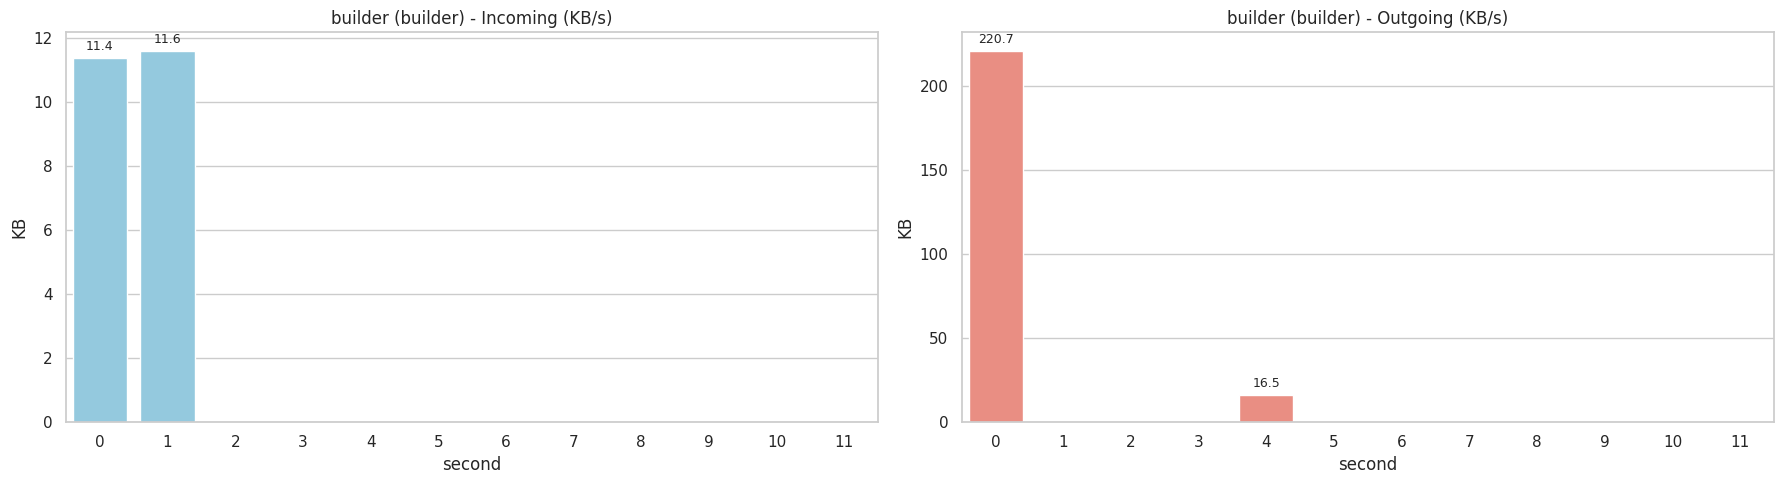

In [14]:
plot_per_second("builder")

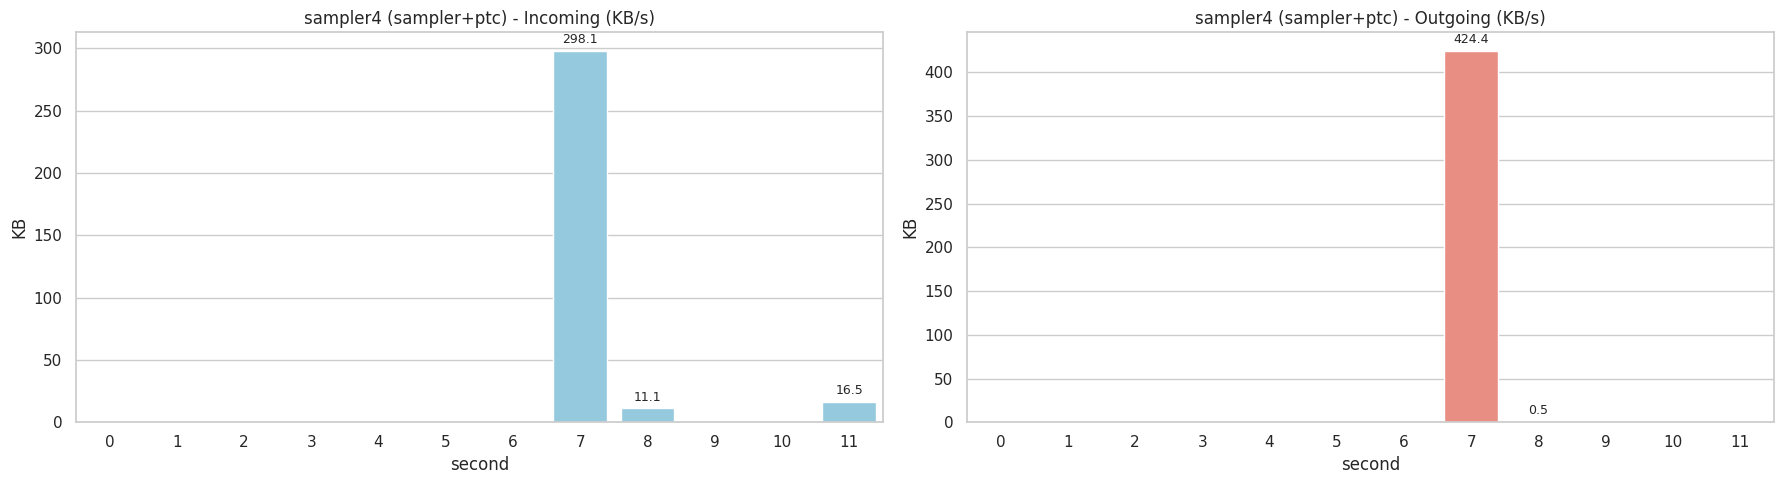

In [15]:
plot_per_second("sampler4")

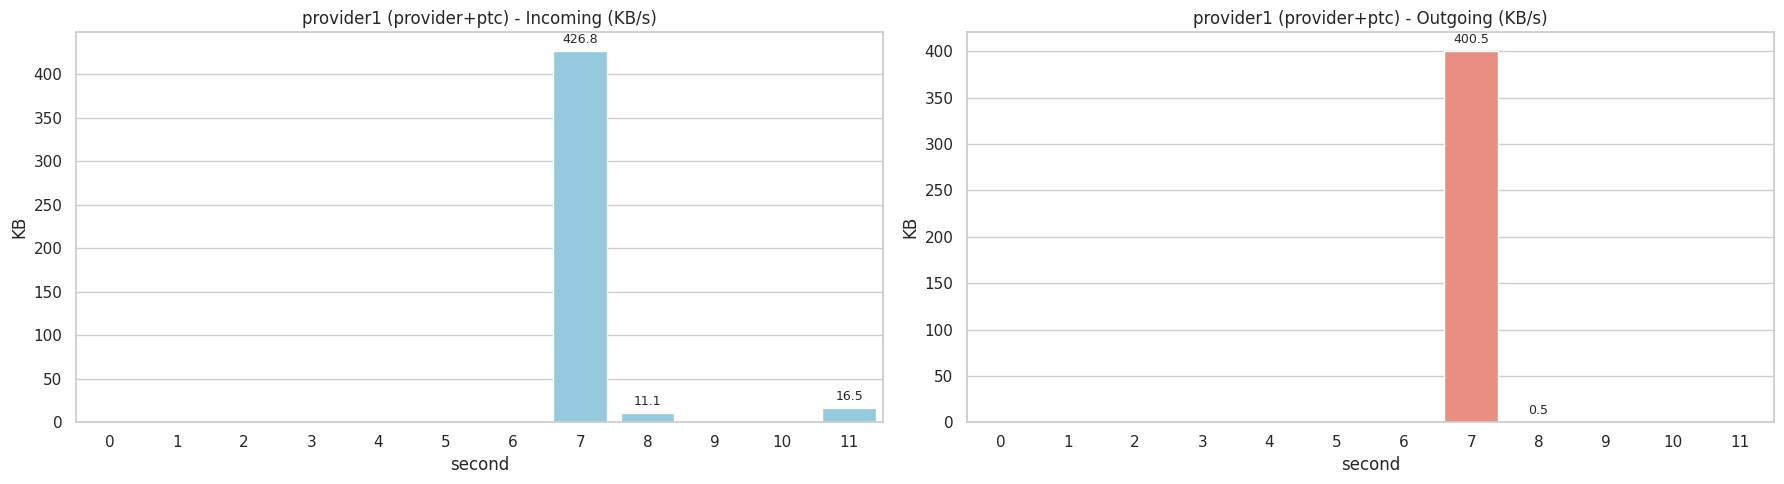

In [16]:
plot_per_second("provider1")

## Aggregate Cluster Analysis

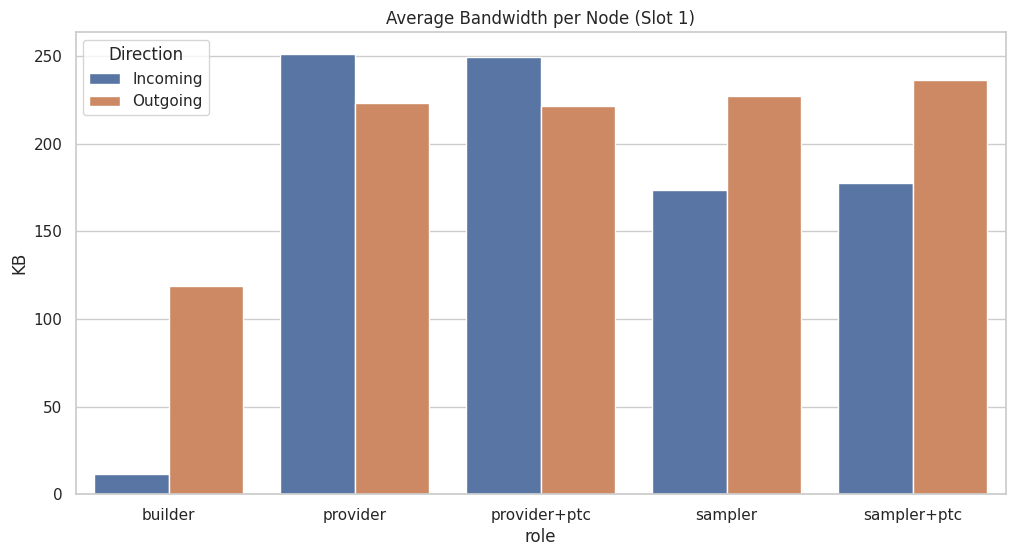

In [17]:
df = parse_aggregate_metrics()
plot_aggregates(df)